<a href="https://www.kaggle.com/code/harshvardhanmehta17/mnist-multiclass-classification?scriptVersionId=332247640" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# **MNIST Multiclass Classification**

## **Importing Dependencies**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.stats import randint
import seaborn as sns

import joblib

In [2]:
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score, RocCurveDisplay, roc_auc_score

In [3]:
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

## **Data Collection & Exploration**

In [4]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

In [5]:
print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [6]:
mnist.details

{'id': '554',
 'name': 'mnist_784',
 'version': '1',
 'description_version': '2',
 'format': 'ARFF',
 'creator': ['Yann LeCun', 'Corinna Cortes', 'Christopher J.C. Burges'],
 'upload_date': '2014-09-29T03:28:38',
 'language': 'English',
 'licence': 'Public',
 'url': 'https://openml.org/data/v1/download/52667/mnist_784.arff',
 'parquet_url': 'https://data.openml.org/datasets/0000/0554/dataset_554.pq',
 'file_id': '52667',
 'default_target_attribute': 'class',
 'tag': ['Artificial Intelligence',
  'AzurePilot',
  'Computer Vision',
  'Data Sets',
  'Kaggle',
  'Machine Learning',
  'OpenML-CC18',
  'OpenML100',
  'study_1',
  'study_123',
  'study_41',
  'study_99',
  'vision'],
 'visibility': 'public',
 'status': 'active',
 'processing_date': '2020-11-20 20:12:09',
 'md5_checksum': '0298d579eb1b86163de7723944c7e495'}

In [7]:
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [8]:
mnist.categories

{'class': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']}

In [9]:
X = mnist.data
Y = mnist.target

In [10]:
X.shape

(70000, 784)

In [11]:
Y.shape

(70000,)

In [12]:
def plot_digit(image_data):
    image = image_data.reshape(28,28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

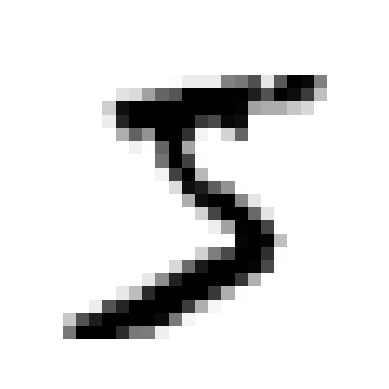

In [13]:
some_digit = X[0]
plot_digit(some_digit)
plt.show()

In [14]:
Y[0]

'5'

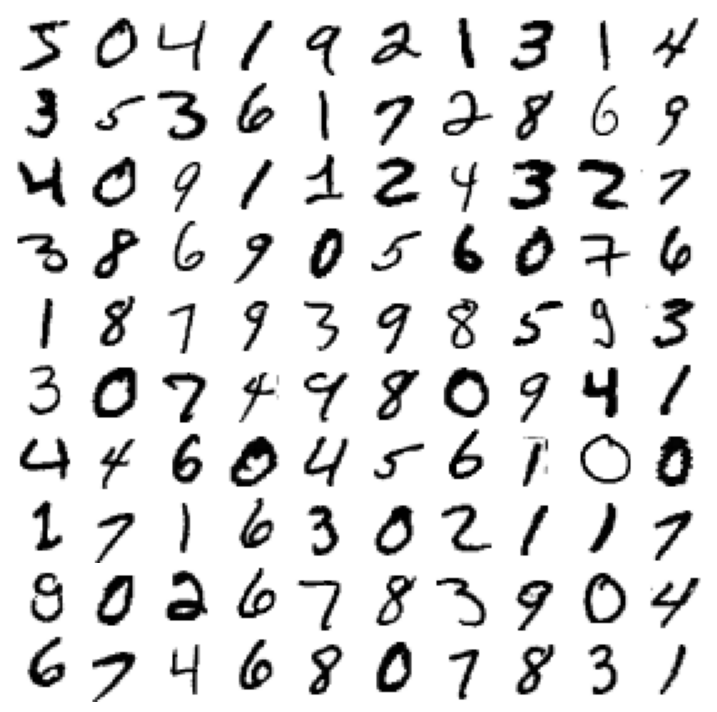

In [15]:
plt.figure(figsize=(9,9))
for idx, image_data in enumerate(X[:100]):
    plt.subplot(10, 10, idx+1)
    plot_digit(image_data)
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

## **Data Spliting**

In [16]:
X_train, X_test, Y_train, Y_test = X[:60000], X[60000:], Y[:60000], Y[60000:]

## **Label Binarization**  

In [17]:
classes = sorted(np.unique(Y_train))
Y_train_bin = label_binarize(Y_train, classes=classes)

## **Model Training & Evaluation**

In [18]:
def evaluate_multiclass_pr_roc_performance(
    Y_true_bin: np.ndarray,
    Y_scores: np.ndarray,
    classes: list[int] | np.ndarray) -> tuple[pd.DataFrame, float, float]:

    """
    Computes and prints detailed Per-Class and Global Macro Performance Metrics (ROC-AUC Score and Average Precision Score) for a
    Multiclass Classification Model.

    Parameters:
    -----------
    Y_true_bin : ndarray of shape (n_samples, n_classes)
                 - Binarized Ground Truth Labels.
    Y_scores : ndarray of shape (n_samples, n_classes)
               - Target Scores / Decision Function Values from the Model.
    classes : list or array of shape (n_classes,)
              - Unique Class Labels.

    Returns:
    --------
    metrics_df : pd.DataFrame
                 - DataFrame containing Per-Class Metrics.
    macro_auc : float
                - Global Macro ROC-AUC Score.
    macro_ap : float
               - Global Macro Average Precision Score.
    """

    performance_metrics = []

    for i in range(len(classes)):
        y_true_class = Y_true_bin[:, i]
        y_score_class = Y_scores[:, i]

        auc_score = roc_auc_score(y_true_class, y_score_class)
        ap_score = average_precision_score(y_true_class, y_score_class)

        performance_metrics.append({
            "Class": classes[i],
            "ROC-AUC Score": f"{auc_score:.4f}",
            "AP Score": f"{ap_score:.4f}"
        })

    metrics_df = pd.DataFrame(performance_metrics)
    print(metrics_df.to_string(index=False))

    macro_auc = roc_auc_score(Y_true_bin, Y_scores, average="macro")
    macro_ap = average_precision_score(Y_true_bin, Y_scores, average="macro")

    print("\n")
    print(f"Macro ROC-AUC Score: {macro_auc:.5f}")
    print(f"Macro Average Precision Score: {macro_ap:.5f}")

    return metrics_df, macro_auc, macro_ap

### **Support Vector Machine (SVM) - RBF Kernel - OneVsOne Strategy**

In [19]:
svm_clf = SVC(kernel='rbf', random_state=3)

In [20]:
svm_clf.fit(X_train, Y_train)

SVC(random_state=3)

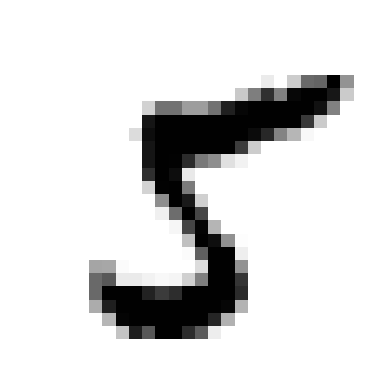

In [21]:
some_digit = X_train[236]
plot_digit(some_digit)
plt.show()

In [22]:
svm_clf.predict([some_digit])

array(['5'], dtype=object)

In [23]:
some_digit_scores = svm_clf.decision_function([some_digit])
some_digit_scores.round(3)

array([[ 4.089,  5.878,  3.731,  8.276,  0.693,  9.318, -0.307,  2.734,
         7.303,  2.729]])

In [24]:
svm_clf.decision_function_shape = "ovr" # default
some_digit_scores_ovr = svm_clf.decision_function([some_digit])
some_digit_scores_ovr.round(3)

array([[ 4.089,  5.878,  3.731,  8.276,  0.693,  9.318, -0.307,  2.734,
         7.303,  2.729]])

In [25]:
svm_clf.decision_function_shape = "ovo"
some_digit_scores_ovo = svm_clf.decision_function([some_digit])
some_digit_scores_ovo.round(3)

array([[-0.049, -0.037, -0.159,  1.029, -1.999,  1.184,  0.462, -0.47 ,
         0.406,  0.743, -0.75 ,  1.006, -2.   ,  0.882,  0.415, -1.289,
         0.365, -0.903,  0.27 , -2.054,  0.611,  0.07 , -1.405, -0.101,
         1.517, -2.423,  1.489,  1.323,  0.04 ,  1.058, -2.524,  0.26 ,
        -1.376, -2.659, -1.481,  3.462,  2.403,  2.   ,  2.601, -0.779,
        -2.191, -0.948, -1.864,  0.417,  2.058]])

In [26]:
svm_clf.decision_function_shape = "ovr"

In [27]:
class_id = some_digit_scores.argmax()
class_id

np.int64(5)

In [28]:
svm_clf.classes_

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

In [29]:
svm_clf.classes_[class_id]

'5'

In [30]:
Y_scores_svm = cross_val_predict(svm_clf, X_train, Y_train, cv=3, method="decision_function")

In [31]:
metrics_df, macro_auc, macro_ap = evaluate_multiclass_pr_roc_performance(Y_train_bin, Y_scores_svm, classes)

Class ROC-AUC Score AP Score
    0        0.9993   0.9968
    1        0.9993   0.9969
    2        0.9960   0.9857
    3        0.9939   0.9801
    4        0.9974   0.9870
    5        0.9961   0.9833
    6        0.9992   0.9949
    7        0.9970   0.9871
    8        0.9936   0.9770
    9        0.9938   0.9751


Macro ROC-AUC Score: 0.99656
Macro Average Precision Score: 0.98638


In [32]:
Y_train_pred_svm = np.argmax(Y_scores_svm, axis=1)

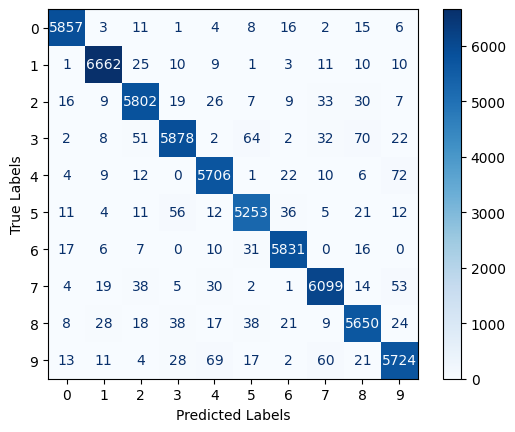

In [33]:
ConfusionMatrixDisplay.from_predictions(Y_train.astype(int), Y_train_pred_svm, cmap='Blues')
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [34]:
print("Accuracy =", accuracy_score(Y_train.astype(int), Y_train_pred_svm))
print("Precision =", precision_score(Y_train.astype(int), Y_train_pred_svm, average="macro"))
print("Recall =", recall_score(Y_train.astype(int), Y_train_pred_svm, average="macro"))
print("F1 Score =", f1_score(Y_train.astype(int), Y_train_pred_svm, average="macro"))

Accuracy = 0.9743666666666667
Precision = 0.9741493060185139
Recall = 0.9741899904495386
F1 Score = 0.97416109819824


In [35]:
print(classification_report(Y_train.astype(int), Y_train_pred_svm))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5923
           1       0.99      0.99      0.99      6742
           2       0.97      0.97      0.97      5958
           3       0.97      0.96      0.97      6131
           4       0.97      0.98      0.97      5842
           5       0.97      0.97      0.97      5421
           6       0.98      0.99      0.98      5918
           7       0.97      0.97      0.97      6265
           8       0.97      0.97      0.97      5851
           9       0.97      0.96      0.96      5949

    accuracy                           0.97     60000
   macro avg       0.97      0.97      0.97     60000
weighted avg       0.97      0.97      0.97     60000



### **Random Forest**

In [36]:
forest_clf = RandomForestClassifier(n_jobs=-1, random_state=3)

In [37]:
forest_clf.fit(X_train, Y_train)

RandomForestClassifier(n_jobs=-1, random_state=3)

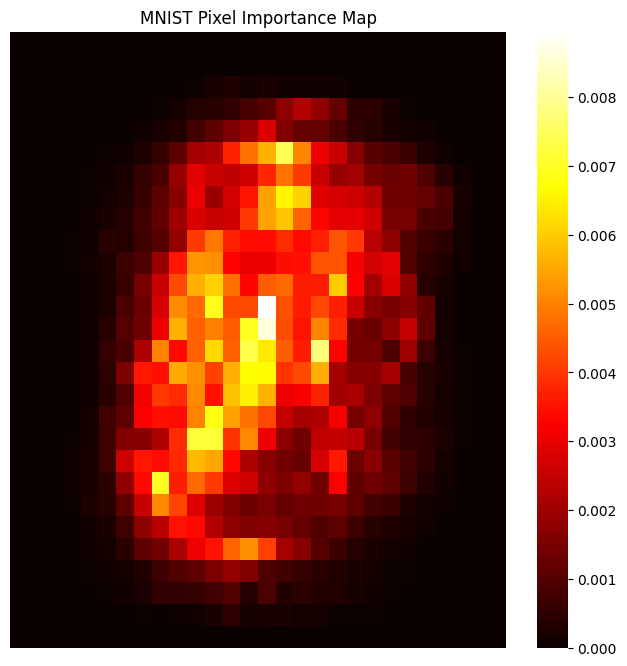

In [38]:
importances = forest_clf.feature_importances_
importance_matrix = importances.reshape(28,28)

plt.figure(figsize=(8,8))
sns.heatmap(importance_matrix, cmap='hot', cbar=True, xticklabels=False, yticklabels=False)
plt.title("MNIST Pixel Importance Map")
plt.show()

In [39]:
Y_probas_forest = cross_val_predict(forest_clf, X_train, Y_train, cv=3, method="predict_proba")

In [40]:
metrics_df, macro_auc, macro_ap = evaluate_multiclass_pr_roc_performance(Y_train_bin, Y_probas_forest, classes)

Class ROC-AUC Score AP Score
    0        0.9997   0.9974
    1        0.9997   0.9983
    2        0.9987   0.9909
    3        0.9976   0.9867
    4        0.9988   0.9927
    5        0.9987   0.9903
    6        0.9997   0.9974
    7        0.9991   0.9935
    8        0.9978   0.9841
    9        0.9974   0.9829


Macro ROC-AUC Score: 0.99872
Macro Average Precision Score: 0.99141


In [41]:
Y_train_pred_forest = np.argmax(Y_probas_forest, axis=1)

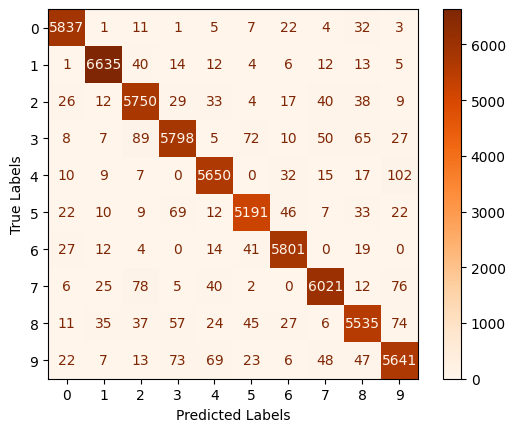

In [42]:
ConfusionMatrixDisplay.from_predictions(Y_train.astype(int), Y_train_pred_forest, cmap='Oranges')
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [43]:
print("Accuracy =", accuracy_score(Y_train.astype(int), Y_train_pred_forest))
print("Precision =", precision_score(Y_train.astype(int), Y_train_pred_forest, average="macro"))
print("Recall =", recall_score(Y_train.astype(int), Y_train_pred_forest, average="macro"))
print("F1 Score =", f1_score(Y_train.astype(int), Y_train_pred_forest, average="macro"))

Accuracy = 0.9643166666666667
Precision = 0.9640274984638445
Recall = 0.9640593440581109
F1 Score = 0.9640265050618476


In [44]:
print(classification_report(Y_train.astype(int), Y_train_pred_forest))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      5923
           1       0.98      0.98      0.98      6742
           2       0.95      0.97      0.96      5958
           3       0.96      0.95      0.95      6131
           4       0.96      0.97      0.97      5842
           5       0.96      0.96      0.96      5421
           6       0.97      0.98      0.98      5918
           7       0.97      0.96      0.97      6265
           8       0.95      0.95      0.95      5851
           9       0.95      0.95      0.95      5949

    accuracy                           0.96     60000
   macro avg       0.96      0.96      0.96     60000
weighted avg       0.96      0.96      0.96     60000



## **Hyperparameter Tuning**

In [45]:
forest_clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 3,
 'verbose': 0,
 'warm_start': False}

In [46]:
param_grid = [
    {"max_features": randint(low=28, high=60),
     "n_estimators": list(range(100, 301, 50)),
     "max_depth": list(range(10, 60)) + [None],
     "min_samples_split": randint(low=2, high=9),
     "max_samples": [0.5, 0.6, 0.7, 0.8, 0.9, None],
    }
]

rnd_search = RandomizedSearchCV(forest_clf, param_distributions=param_grid, n_iter=20, cv=3, scoring="f1_macro", random_state=3, n_jobs=-1)

In [47]:
rnd_search.fit(X_train, Y_train)

RandomizedSearchCV(cv=3,
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=3),
                   n_iter=20, n_jobs=-1,
                   param_distributions=[{'max_depth': [10, 11, 12, 13, 14, 15,
                                                       16, 17, 18, 19, 20, 21,
                                                       22, 23, 24, 25, 26, 27,
                                                       28, 29, 30, 31, 32, 33,
                                                       34, 35, 36, 37, 38, 39, ...],
                                         'max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x78d9c037ce30>,
                                         'max_samples': [0.5, 0.6, 0.7, 0.8,
                                                         0.9, None],
                                         'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x78d9c02fe780>,
                                         'n_estimators': [100, 150, 200, 250,
                                                          300]}],
                   random_state=3, scoring='f1_macro')

In [48]:
rnd_search.best_params_

{'max_depth': 53,
 'max_features': 56,
 'max_samples': 0.9,
 'min_samples_split': 5,
 'n_estimators': 250}

In [49]:
cv_res = pd.DataFrame(rnd_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)

cv_res = cv_res[["param_max_depth", "param_max_features", "param_max_samples", "param_min_samples_split", "param_n_estimators", 
                 "split0_test_score", "split1_test_score", "split2_test_score", "mean_test_score"]]
score_cols = ["split0", "split1", "split2", "mean_test_f1"]
cv_res.columns = ["max_depth", "max_features", "max_samples", "min_samples_split", "n_estimators"] + score_cols
cv_res[score_cols] = cv_res[score_cols].round(4)

cv_res.head(n=10)

,max_depth,max_features,max_samples,min_samples_split,n_estimators,split0,split1,split2,mean_test_f1
14,53,56,0.9,5,250,0.9644,0.9627,0.9663,0.9645
7,56,29,None,4,100,0.9652,0.9623,0.9655,0.9644
9,25,44,None,6,150,0.9648,0.9621,0.9654,0.9641
5,36,50,0.7,4,300,0.9652,0.9620,0.9652,0.9641
13,59,29,None,7,200,0.9643,0.9628,0.9652,0.9641
19,54,44,0.8,4,100,0.9635,0.9615,0.9654,0.9635
1,18,28,None,7,250,0.9639,0.9599,0.9653,0.9631
10,31,59,0.9,6,100,0.9627,0.9611,0.9649,0.9629
16,None,46,0.8,2,100,0.9639,0.9597,0.9647,0.9628
8,17,52,0.8,3,250,0.9629,0.9614,0.9638,0.9627


In [50]:
best_rf_score = rnd_search.best_score_
best_rf_score

np.float64(0.9644513541191442)

In [51]:
best_rf = rnd_search.best_estimator_

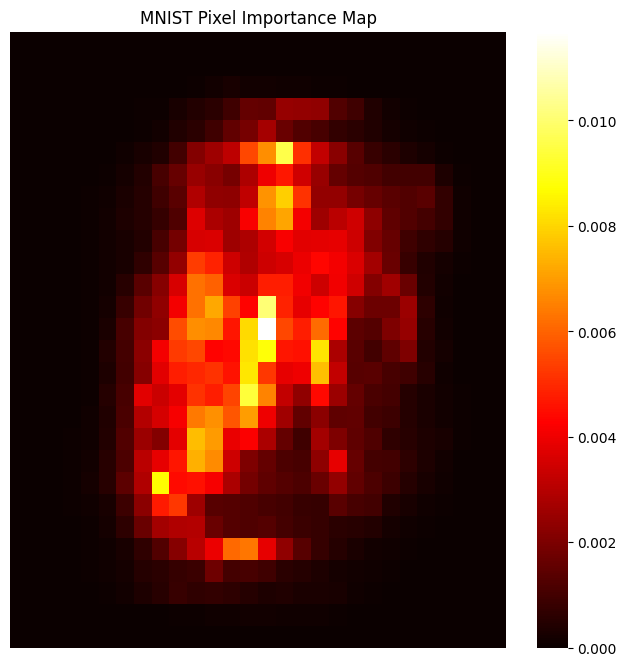

In [52]:
importances = best_rf.feature_importances_
importance_matrix = importances.reshape(28,28)

plt.figure(figsize=(8,8))
sns.heatmap(importance_matrix, cmap='hot', cbar='True', xticklabels=False, yticklabels=False)
plt.title("MNIST Pixel Importance Map")
plt.show()

## **Final Model Selection & Evaluation** 

In [53]:
final_model = svm_clf

In [54]:
final_model.fit(X_train, Y_train)

SVC(random_state=3)

In [55]:
hasattr(final_model, 'predict_proba')

False

In [56]:
hasattr(final_model, 'decision_function')

True

In [57]:
Y_test_scores = final_model.decision_function(X_test)

In [58]:
Y_test_pred = np.argmax(Y_test_scores, axis=1)

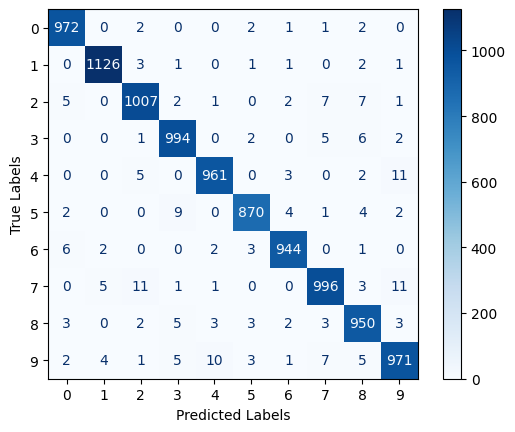

In [59]:
ConfusionMatrixDisplay.from_predictions(Y_test.astype(int), Y_test_pred, cmap='Blues')
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [60]:
print("Accuracy =", accuracy_score(Y_test.astype(int), Y_test_pred))
print("Precision =", precision_score(Y_test.astype(int), Y_test_pred, average="macro"))
print("Recall =", recall_score(Y_test.astype(int), Y_test_pred, average="macro"))
print("F1 Score =", f1_score(Y_test.astype(int), Y_test_pred, average="macro"))

Accuracy = 0.9791
Precision = 0.9790415868064832
Recall = 0.978974833206428
F1 Score = 0.9789977451972017


In [61]:
print(classification_report(Y_test.astype(int), Y_test_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.99      0.99      0.99       958
           7       0.98      0.97      0.97      1028
           8       0.97      0.98      0.97       974
           9       0.97      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [62]:
classes = np.arange(10)
Y_test_bin = label_binarize(Y_test.astype(int), classes=classes)
metrics_df, macro_auc, macro_ap = evaluate_multiclass_pr_roc_performance(Y_test_bin, Y_test_scores, classes)

 Class ROC-AUC Score AP Score
     0        0.9992   0.9965
     1        0.9998   0.9987
     2        0.9960   0.9877
     3        0.9968   0.9903
     4        0.9984   0.9894
     5        0.9987   0.9920
     6        0.9988   0.9941
     7        0.9968   0.9871
     8        0.9957   0.9838
     9        0.9935   0.9746


Macro ROC-AUC Score: 0.99738
Macro Average Precision Score: 0.98942


In [63]:
joblib.dump(final_model, "mnist_multi_svm_rbf.pkl", compress=3)
print("Success!!")

Success!!
